## IMDB Data Analysis: Loading and Transforming Movie Datasets with Pandas

In [57]:
import pandas as pd

In [58]:
df=pd.read_csv('/content/movies.csv')

df.sample(3)

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
6254,tt14912006,Bull Shark,2022,2.7,TV-14,80 min,"Action, Drama, Horror",343,"52,709",nm5472963,Brett Bentman,"nm2465485,nm3046228,nm4129626,nm3250181","Thom Hallum,Billy Blair,Lindsey Marie Wilson,D...",A hungry shark begins feeding on unsuspecting ...
8678,tt4044364,第四公民,2014,8.0,R,114 min,"Documentary, Biography, History",55375,"2,800,870",nm0688636,Laura Poitras,"nm5722984,nm3390925,nm5015568,nm3335834","Edward Snowden,Glenn Greenwald,William Binney,...",A documentarian and a reporter travel to Hong ...
12594,tt0411302,Doodlebug,1997,7.0,Not Rated,3 min,"Short, Action, Fantasy","17,690","1,107,148","/name/nm0634240/,/name/nm0857458/","Christopher Nolan,Jeremy Theobald",nm0857458,Jeremy Theobald,"In his squalid apartment, a man tries to squas..."


In [59]:
#to get information of the df about its datatype & count of records excluding null
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19808 entries, 0 to 19807
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              19808 non-null  object 
 1   name            19808 non-null  object 
 2   year            19808 non-null  int64  
 3   rating          19808 non-null  float64
 4   certificate     19808 non-null  object 
 5   duration        19808 non-null  object 
 6   genre           19808 non-null  object 
 7   votes           19808 non-null  object 
 8   gross_income    19808 non-null  object 
 9   directors_id    19808 non-null  object 
 10  directors_name  19808 non-null  object 
 11  stars_id        19808 non-null  object 
 12  stars_name      19808 non-null  object 
 13  description     19808 non-null  object 
dtypes: float64(1), int64(1), object(12)
memory usage: 2.1+ MB


In [60]:
#generates a quick summary of descriptive statistics for DataFrame.
df.describe()

,year,rating
count,19808.000000,19808.000000
mean,1995.546597,6.041973
std,22.801725,1.206831
min,1894.000000,1.100000
25%,1983.000000,5.300000
50%,2003.000000,6.200000
75%,2014.000000,6.900000
max,2022.000000,9.700000


In [61]:
# Check for missing values across columns; .isnull() flags missing data as True/False,
# and .sum() aggregates those True values to return the total null count per column.
df.isnull().sum()

,0
id,0
name,0
year,0
rating,0
certificate,0
duration,0
genre,0
votes,0
gross_income,0
directors_id,0


###**Data cleaning**

In [62]:
#how do we clean duration column

In [63]:
# To analyze a specific column (like 'duration'), chain it with a built-in method.
# Here, .count() returns the total number of non-null values in the 'duration' column.
df['duration'].count()

np.int64(19808)

In [64]:
# Remove non-numeric characters ('min' and ',') from the 'duration' column.
df['duration']=df['duration'].str.replace('min','')
df['duration']=df['duration'].str.replace(',','')


In [65]:
#convert to int type
df['duration']=df['duration'].astype(int)

In [66]:
#remove the below non-numeric characters from 'gross_income' and convert it to float
df['gross_income']=df['gross_income'].str.replace(',','')
df['gross_income']=df['gross_income'].str.replace('$','')
df['gross_income']=df['gross_income'].str.replace('M','')
df['gross_income']=df['gross_income'].astype(float)

In [67]:
#remove the below non-numeric characters from 'votes' and convert it to int
df['votes']=df['votes'].str.replace(',','')
df['votes']=df['votes'].astype(int)
df.head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt0068646,The Godfather,1972,9.2,R,175,"Crime, Drama",1798749,134966411.0,nm0000338,Francis Ford Coppola,"nm0000008,nm0000199,nm0001001,nm0000473","Marlon Brando,Al Pacino,James Caan,Diane Keaton",The aging patriarch of an organized crime dyna...
1,tt5113044,Minions: The Rise of Gru,2022,7.3,PG,87,"Animation, Adventure, Comedy",1220,134966411.0,"nm0049633,nm1556070,nm3646390","Kyle Balda,Brad Ableson,Jonathan del Val","nm0136797,nm1853544,nm0000273,nm0378245","Steve Carell,Pierre Coffin,Alan Arkin,Taraji P...",The untold story of one twelve-year-old's drea...
2,tt7657566,Death on the Nile,2022,6.3,PG-13,127,"Crime, Drama, Mystery",121063,134966411.0,nm0000110,Kenneth Branagh,"nm5290643,nm0000906,nm0000110,nm1258970","Tom Bateman,Annette Bening,Kenneth Branagh,Rus...","While on vacation on the Nile, Hercule Poirot ..."
3,tt8115900,The Bad Guys,2022,6.9,PG,100,"Animation, Adventure, Comedy",23090,134966411.0,nm2010048,Pierre Perifel,"nm0005377,nm0549505,nm5377144,nm0732497","Sam Rockwell,Marc Maron,Awkwafina,Craig Robinson",Several reformed yet misunderstood criminal an...
4,tt10809742,Collision,2022,3.8,TV-MA,99,"Crime, Drama, Thriller",656,134966411.0,nm1926494,Fabien Martorell,"nm1339181,nm0456810,nm12651040,nm7357127","Tessa Jubber,Langley Kirkwood,Zoey Sneedon,Bon...",Freedom always comes at a price.


###**Selecting data from a Dataframe**

In [68]:
# Select records with rating = 6
df[df['rating']==6]


,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
52,tt0116743,Kama Sutra: A Tale of Love,1996,6.0,R,114,"Crime, Drama, History",10666,4109095.0,nm0619762,Mira Nair,"nm0004710,nm0002004,nm0890055,nm0863130","Naveen Andrews,Sarita Choudhury,Indira Varma,R...",Two female friends become sexual rivals at mat...
66,tt7713068,Birds of Prey,2020,6.0,R,109,"Action, Adventure, Comedy",230704,84158461.0,nm4014166,Cathy Yan,"nm3053338,nm0001609,nm0935541,nm0810619","Margot Robbie,Rosie Perez,Mary Elizabeth Winst...","After splitting with the Joker, Harley Quinn j..."
172,tt1618434,Murder Mystery,2019,6.0,PG-13,97,"Action, Comedy, Crime",124045,87341380.0,nm1760830,Kyle Newacheck,"nm0001191,nm0000098,nm1812656,nm0000654","Adam Sandler,Jennifer Aniston,Luke Evans,Teren...",A New York cop and his wife go on a European v...
185,tt6246322,Don't Breathe 2,2021,6.0,R,98,"Action, Crime, Thriller",51871,32638038.0,nm2140186,Rodo Sayagues,"nm0002332,nm6388677,nm0786639,nm9318242","Stephen Lang,Madelyn Grace,Brendan Sexton III,...",The sequel is set in the years following the i...
190,tt0463985,The Fast and the Furious: Tokyo Drift,2006,6.0,PG-13,104,"Action, Adventure, Crime",267548,62514415.0,nm0510912,Justin Lin,"nm0085407,nm0117022,nm0510168,nm2179185","Lucas Black,Zachery Ty Bryan,Shad Moss,Damien ...",A teenager becomes a major competitor in the w...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19634,tt0078044,The Other Side of the Mountain: Part II,1978,6.0,PG,100,"Biography, Drama, Romance",352,11565678.0,nm0670282,Larry Peerce,"nm0368472,nm0000961,nm0552832,nm0599727","Marilyn Hassett,Timothy Bottoms,Nan Martin,Bel...",Several years after the deaths of Dick Buek an...
19635,tt0076567,The Private Files of J. Edgar Hoover,1977,6.0,PG,112,"Biography, Drama",727,132409.0,nm0169540,Larry Cohen,"nm0002024,nm0906535,nm0662981,nm0001207","Broderick Crawford,James Wainwright,Michael Pa...","The story of the late J. Edgar Hoover, who was..."
19664,tt0808392,Neal Cassady,2007,6.0,Not Rated,80,"Biography, Drama",207,1229782.0,nm1231757,Noah Buschel,"nm0004883,nm0752407,nm0280245,nm0061777","Tate Donovan,Amy Ryan,Glenn Fitzgerald,Chris B...",The story of what happened to Neal Cassady aft...
19724,tt0049461,Magic Fire,1955,6.0,Approved,120,"Biography, Drama",158,194721.0,nm0226189,William Dieterle,"nm0001119,nm0859939,nm0303601,nm0181305","Yvonne De Carlo,Carlos Thompson,Rita Gam,Valen...",The life and career of German composer Richard...


In [69]:
#Select records with Rating >6
df[df['rating']>6]

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt0068646,The Godfather,1972,9.2,R,175,"Crime, Drama",1798749,134966411.0,nm0000338,Francis Ford Coppola,"nm0000008,nm0000199,nm0001001,nm0000473","Marlon Brando,Al Pacino,James Caan,Diane Keaton",The aging patriarch of an organized crime dyna...
1,tt5113044,Minions: The Rise of Gru,2022,7.3,PG,87,"Animation, Adventure, Comedy",1220,134966411.0,"nm0049633,nm1556070,nm3646390","Kyle Balda,Brad Ableson,Jonathan del Val","nm0136797,nm1853544,nm0000273,nm0378245","Steve Carell,Pierre Coffin,Alan Arkin,Taraji P...",The untold story of one twelve-year-old's drea...
2,tt7657566,Death on the Nile,2022,6.3,PG-13,127,"Crime, Drama, Mystery",121063,134966411.0,nm0000110,Kenneth Branagh,"nm5290643,nm0000906,nm0000110,nm1258970","Tom Bateman,Annette Bening,Kenneth Branagh,Rus...","While on vacation on the Nile, Hercule Poirot ..."
3,tt8115900,The Bad Guys,2022,6.9,PG,100,"Animation, Adventure, Comedy",23090,134966411.0,nm2010048,Pierre Perifel,"nm0005377,nm0549505,nm5377144,nm0732497","Sam Rockwell,Marc Maron,Awkwafina,Craig Robinson",Several reformed yet misunderstood criminal an...
5,tt0071562,The Godfather Part II,1974,9.0,R,202,"Crime, Drama",1239038,57300000.0,nm0000338,Francis Ford Coppola,"nm0000199,nm0000134,nm0000380,nm0000473","Al Pacino,Robert De Niro,Robert Duvall,Diane K...",The early life and career of Vito Corleone in ...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19803,tt0459423,Kahaani Gudiya Ki...: True Story of a Woman,2008,6.2,Not Rated,112,"Biography, Drama",41,44435.0,nm1909606,Prabhakar Shukla,"nm0244890,nm0952232,nm1056425,nm6389513","Divya Dutta,Arif Zakaria,Rajpal Naurang Yadav,...","A tragic saga about a woman named Gudiya, whos..."
19804,tt0119621,Mark Twain's America in,1998,6.5,G,52,"Documentary, Biography",48,2281741.0,nm0522844,Stephen Low,"nm0000843,nm0640297,nm4700843,nm1838044","Anne Bancroft,Dennis O'Connor,Kim Parr,LeeAnn ...",Interweaves Twain's life and times with the li...
19805,tt0168950,Let It Come Down: The Life of Paul Bowles,1998,6.9,Not Rated,75,"Documentary, Biography",125,9188.0,nm0047028,Jennifer Baichwal,"nm0101247,nm0123221,nm0155822,nm0159383","Paul Bowles,William S. Burroughs,Cherifa,Moham...",Add a Plot
19806,tt0267563,Hybrid,2000,7.4,Not Rated,92,"Documentary, Biography",146,159403.0,"/name/nm0566144/,/name/nm1084921/","Monteith McCollum,Milford Beeghly",nm1084921,Milford Beeghly,The life story of Milford Beeghly: Iowa farmer...


In [70]:
# to find a row through index

df.loc[19807]

,19807
id,tt0116481
name,Hands on a Hardbody: The Documentary
year,1997
rating,7.6
certificate,PG
duration,98
genre,"Documentary, Comedy, Drama"
votes,2167
gross_income,492876.0
directors_id,nm0082835


In [71]:
# Select two or more columns by passing it into a list
df[['rating','votes']]

,rating,votes
0,9.2,1798749
1,7.3,1220
2,6.3,121063
3,6.9,23090
4,3.8,656
...,...,...
19803,6.2,41
19804,6.5,48
19805,6.9,125
19806,7.4,146


In [72]:
df.describe()

,year,rating,duration,votes,gross_income
count,19808.000000,19808.000000,19808.000000,1.980800e+04,1.980800e+04
mean,1995.546597,6.041973,101.777968,3.694303e+04,1.682198e+07
std,22.801725,1.206831,43.178721,1.129755e+05,4.642034e+07
min,1894.000000,1.100000,1.000000,5.000000e+00,0.000000e+00
25%,1983.000000,5.300000,90.000000,1.058000e+03,1.196010e+05
50%,2003.000000,6.200000,98.000000,4.233000e+03,1.158192e+06
75%,2014.000000,6.900000,111.000000,2.045350e+04,1.243278e+07
max,2022.000000,9.700000,5220.000000,2.574832e+06,9.366622e+08


In [73]:
# Filter for exceptionally high ratings that sit above the 75th percentile threshold. (value calculated by df.describe())
df[df['rating']>6.9].head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt0068646,The Godfather,1972,9.2,R,175,"Crime, Drama",1798749,134966411.0,nm0000338,Francis Ford Coppola,"nm0000008,nm0000199,nm0001001,nm0000473","Marlon Brando,Al Pacino,James Caan,Diane Keaton",The aging patriarch of an organized crime dyna...
1,tt5113044,Minions: The Rise of Gru,2022,7.3,PG,87,"Animation, Adventure, Comedy",1220,134966411.0,"nm0049633,nm1556070,nm3646390","Kyle Balda,Brad Ableson,Jonathan del Val","nm0136797,nm1853544,nm0000273,nm0378245","Steve Carell,Pierre Coffin,Alan Arkin,Taraji P...",The untold story of one twelve-year-old's drea...
5,tt0071562,The Godfather Part II,1974,9.0,R,202,"Crime, Drama",1239038,57300000.0,nm0000338,Francis Ford Coppola,"nm0000199,nm0000134,nm0000380,nm0000473","Al Pacino,Robert De Niro,Robert Duvall,Diane K...",The early life and career of Vito Corleone in ...
9,tt0071771,The Longest Yard,1974,7.1,R,121,"Comedy, Crime, Drama",19000,7130696.0,nm0000736,Robert Aldrich,"nm0000608,nm0000734,nm0491590,nm0175700","Burt Reynolds,Eddie Albert,Ed Lauter,Michael C...",A sadistic warden asks a former pro quarterbac...
10,tt0993846,The Wolf of Wall Street,2013,8.2,R,180,"Biography, Comedy, Crime",1352516,116900694.0,nm0000217,Martin Scorsese,"nm0000138,nm1706767,nm3053338,nm0000190","Leonardo DiCaprio,Jonah Hill,Margot Robbie,Mat...","Based on the true story of Jordan Belfort, fro..."


In [74]:
# Instead of hardcoding values found from describe() , we can use quantile to get dynamic values , even if your data changes in future
p_high_rating=df['rating'].quantile(0.75)
df[df['rating']>p_high_rating].head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt0068646,The Godfather,1972,9.2,R,175,"Crime, Drama",1798749,134966411.0,nm0000338,Francis Ford Coppola,"nm0000008,nm0000199,nm0001001,nm0000473","Marlon Brando,Al Pacino,James Caan,Diane Keaton",The aging patriarch of an organized crime dyna...
1,tt5113044,Minions: The Rise of Gru,2022,7.3,PG,87,"Animation, Adventure, Comedy",1220,134966411.0,"nm0049633,nm1556070,nm3646390","Kyle Balda,Brad Ableson,Jonathan del Val","nm0136797,nm1853544,nm0000273,nm0378245","Steve Carell,Pierre Coffin,Alan Arkin,Taraji P...",The untold story of one twelve-year-old's drea...
5,tt0071562,The Godfather Part II,1974,9.0,R,202,"Crime, Drama",1239038,57300000.0,nm0000338,Francis Ford Coppola,"nm0000199,nm0000134,nm0000380,nm0000473","Al Pacino,Robert De Niro,Robert Duvall,Diane K...",The early life and career of Vito Corleone in ...
9,tt0071771,The Longest Yard,1974,7.1,R,121,"Comedy, Crime, Drama",19000,7130696.0,nm0000736,Robert Aldrich,"nm0000608,nm0000734,nm0491590,nm0175700","Burt Reynolds,Eddie Albert,Ed Lauter,Michael C...",A sadistic warden asks a former pro quarterbac...
10,tt0993846,The Wolf of Wall Street,2013,8.2,R,180,"Biography, Comedy, Crime",1352516,116900694.0,nm0000217,Martin Scorsese,"nm0000138,nm1706767,nm3053338,nm0000190","Leonardo DiCaprio,Jonah Hill,Margot Robbie,Mat...","Based on the true story of Jordan Belfort, fro..."


In [75]:

df[df['votes']<1058]

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
4,tt10809742,Collision,2022,3.8,TV-MA,99,"Crime, Drama, Thriller",656,134966411.0,nm1926494,Fabien Martorell,"nm1339181,nm0456810,nm12651040,nm7357127","Tessa Jubber,Langley Kirkwood,Zoey Sneedon,Bon...",Freedom always comes at a price.
33,tt13479592,Centaur,2022,5.3,TV-MA,89,"Action, Adventure, Crime",791,58009200.0,nm0130714,Daniel Calparsoro,"nm3856284,nm9603580,nm10257702,nm5379183","Àlex Monner,Begoña Vargas,Abraham Pérez Fernán...","Rafa's hooked on the pure, fiery feelings he g..."
47,tt1551614,Blowback,2022,4.4,R,93,"Action, Crime, Thriller",199,74283625.0,nm0847749,Tibor Takács,"nm1330276,nm1544217,nm6029604,nm0541909","Randy Couture,Cam Gigandet,Michele Plaia,Louis...","After planning a perfect heist, Nick is ready ..."
463,tt0148615,Play Motel,1979,4.8,X,93,"Crime, Horror, Mystery",545,69304264.0,nm0307391,Mario Gariazzo,"nm0522590,nm0729940,nm0193892,nm0029738","Ray Lovelock,Anna Maria Rizzoli,Mario Cutini,A...",A reporter and his girlfriend investigate deat...
565,tt0026184,The Case of the Curious Bride,1935,6.6,Passed,80,"Comedy, Crime, Drama",1031,2395231.0,nm0002031,Michael Curtiz,"nm0929925,nm0512267,nm0940579,nm0230068","Warren William,Margaret Lindsay,Donald Woods,C...",Perry interrupts his vacation plans when an ex...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19802,tt1518255,Raw Faith,2010,8.3,Not Rated,94,"Documentary, Biography, Drama",71,1486.0,"/name/nm0927286/,/name/nm3628867/","Wm. Peter Wiedensmith,Marilyn Sewell",nm3628867,Marilyn Sewell,This surprisingly open and revealing documenta...
19803,tt0459423,Kahaani Gudiya Ki...: True Story of a Woman,2008,6.2,Not Rated,112,"Biography, Drama",41,44435.0,nm1909606,Prabhakar Shukla,"nm0244890,nm0952232,nm1056425,nm6389513","Divya Dutta,Arif Zakaria,Rajpal Naurang Yadav,...","A tragic saga about a woman named Gudiya, whos..."
19804,tt0119621,Mark Twain's America in,1998,6.5,G,52,"Documentary, Biography",48,2281741.0,nm0522844,Stephen Low,"nm0000843,nm0640297,nm4700843,nm1838044","Anne Bancroft,Dennis O'Connor,Kim Parr,LeeAnn ...",Interweaves Twain's life and times with the li...
19805,tt0168950,Let It Come Down: The Life of Paul Bowles,1998,6.9,Not Rated,75,"Documentary, Biography",125,9188.0,nm0047028,Jennifer Baichwal,"nm0101247,nm0123221,nm0155822,nm0159383","Paul Bowles,William S. Burroughs,Cherifa,Moham...",Add a Plot


In [76]:
# low votes using quantile
p_low_votes=df['votes'].quantile(0.25)
df[df['votes']<p_low_votes].head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
4,tt10809742,Collision,2022,3.8,TV-MA,99,"Crime, Drama, Thriller",656,134966411.0,nm1926494,Fabien Martorell,"nm1339181,nm0456810,nm12651040,nm7357127","Tessa Jubber,Langley Kirkwood,Zoey Sneedon,Bon...",Freedom always comes at a price.
33,tt13479592,Centaur,2022,5.3,TV-MA,89,"Action, Adventure, Crime",791,58009200.0,nm0130714,Daniel Calparsoro,"nm3856284,nm9603580,nm10257702,nm5379183","Àlex Monner,Begoña Vargas,Abraham Pérez Fernán...","Rafa's hooked on the pure, fiery feelings he g..."
47,tt1551614,Blowback,2022,4.4,R,93,"Action, Crime, Thriller",199,74283625.0,nm0847749,Tibor Takács,"nm1330276,nm1544217,nm6029604,nm0541909","Randy Couture,Cam Gigandet,Michele Plaia,Louis...","After planning a perfect heist, Nick is ready ..."
463,tt0148615,Play Motel,1979,4.8,X,93,"Crime, Horror, Mystery",545,69304264.0,nm0307391,Mario Gariazzo,"nm0522590,nm0729940,nm0193892,nm0029738","Ray Lovelock,Anna Maria Rizzoli,Mario Cutini,A...",A reporter and his girlfriend investigate deat...
565,tt0026184,The Case of the Curious Bride,1935,6.6,Passed,80,"Comedy, Crime, Drama",1031,2395231.0,nm0002031,Michael Curtiz,"nm0929925,nm0512267,nm0940579,nm0230068","Warren William,Margaret Lindsay,Donald Woods,C...",Perry interrupts his vacation plans when an ex...


In [77]:
# Find the "Hidden Gems" (High Rating(more than 75%), Low Votes(less than 25%))
df[(df['votes']<1058) & (df['rating']>6.9)].head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
3423,tt4106286,Tiny Detectives,2014,7.2,TV-14,2,"Short, Comedy, Crime",536,1501277.0,nm0124089,Andrew Bush,"nm0680983,nm0544718,nm1930273,nm7534064","Elliot Page,Kate Mara,DeMorge Brown,Jaclyn Fle...","A parody of True Detective about two short, fe..."
3502,tt0042953,Shakedown,1950,7.0,Approved,80,"Crime, Drama, Film-Noir",346,6310.0,nm0678928,Joseph Pevney,"nm0003318,nm0235627,nm0002046,nm0862937","Howard Duff,Peggy Dow,Brian Donlevy,Lawrence T...",Unscrupulous and opportunistic San Francisco n...
3522,tt0070552,High Crime,1973,7.0,R,100,"Crime, Drama, Thriller",885,1404.0,nm0144758,Enzo G. Castellari,"nm0626259,nm0721073,nm0926235,nm0090521","Franco Nero,Fernando Rey,James Whitmore,Delia ...",An Italian police inspector matches wits with ...
3594,tt0246879,Qurbani,1980,7.0,Not Rated,157,"Action, Crime, Drama",886,398420.0,nm0451211,Feroz Khan,"nm0451211,nm0451396,nm0023868,nm0451166","Feroz Khan,Vinod Khanna,Zeenat Aman,Amjad Khan",Two friends live happily until misunderstandin...
3980,tt13634096,The Bacon Hair,2020,8.5,TV-14,76,"Animation, Action, Adventure",90,852206.0,nm9762716,ObliviousHD,"nm5055725,nm10194796,nm12142163,nm0746445","Leah Ashley,Tom Aglio,Gen Sherard,Graham Rowat",Surrounded by towering walls and patrolled by ...


In [78]:
#high rating , low votes using quantile
df[(df['rating']>p_high_rating) & (df['votes']<p_low_votes)].head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
3423,tt4106286,Tiny Detectives,2014,7.2,TV-14,2,"Short, Comedy, Crime",536,1501277.0,nm0124089,Andrew Bush,"nm0680983,nm0544718,nm1930273,nm7534064","Elliot Page,Kate Mara,DeMorge Brown,Jaclyn Fle...","A parody of True Detective about two short, fe..."
3502,tt0042953,Shakedown,1950,7.0,Approved,80,"Crime, Drama, Film-Noir",346,6310.0,nm0678928,Joseph Pevney,"nm0003318,nm0235627,nm0002046,nm0862937","Howard Duff,Peggy Dow,Brian Donlevy,Lawrence T...",Unscrupulous and opportunistic San Francisco n...
3522,tt0070552,High Crime,1973,7.0,R,100,"Crime, Drama, Thriller",885,1404.0,nm0144758,Enzo G. Castellari,"nm0626259,nm0721073,nm0926235,nm0090521","Franco Nero,Fernando Rey,James Whitmore,Delia ...",An Italian police inspector matches wits with ...
3594,tt0246879,Qurbani,1980,7.0,Not Rated,157,"Action, Crime, Drama",886,398420.0,nm0451211,Feroz Khan,"nm0451211,nm0451396,nm0023868,nm0451166","Feroz Khan,Vinod Khanna,Zeenat Aman,Amjad Khan",Two friends live happily until misunderstandin...
3980,tt13634096,The Bacon Hair,2020,8.5,TV-14,76,"Animation, Action, Adventure",90,852206.0,nm9762716,ObliviousHD,"nm5055725,nm10194796,nm12142163,nm0746445","Leah Ashley,Tom Aglio,Gen Sherard,Graham Rowat",Surrounded by towering walls and patrolled by ...


In [79]:
# Find the "Overhyped" movies (Low Rating(less than 25%), High Gross(more than 75%))
df[(df['rating']<5.3) & (df['gross_income']>1243278)]

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
4,tt10809742,Collision,2022,3.8,TV-MA,99,"Crime, Drama, Thriller",656,134966411.0,nm1926494,Fabien Martorell,"nm1339181,nm0456810,nm12651040,nm7357127","Tessa Jubber,Langley Kirkwood,Zoey Sneedon,Bon...",Freedom always comes at a price.
18,tt11656220,Midnight in the Switchgrass,2021,4.4,R,99,"Action, Crime, Thriller",6827,107928762.0,nm0256542,Randall Emmett,"nm0386472,nm1083271,nm0000246,nm0001305","Emile Hirsch,Megan Fox,Bruce Willis,Lukas Haas",An FBI agent and Florida State officer team up...
37,tt6749318,Speed Kills,2018,4.2,R,102,"Action, Crime, Drama",3381,130742922.0,nm9928566,Jodi Scurfield,"nm0000237,nm0935395,nm0261170,nm0922995","John Travolta,Katheryn Winnick,Jennifer Esposi...",Speedboat racing champion and multimillionaire...
40,tt5433138,F9: The Fast Saga,2021,5.2,PG-13,143,"Action, Crime, Thriller",125648,173202780.0,nm0510912,Justin Lin,"nm0004874,nm0735442,nm0108287,nm0879085","Vin Diesel,Michelle Rodriguez,Jordana Brewster...",Dom and the crew must take on an international...
47,tt1551614,Blowback,2022,4.4,R,93,"Action, Crime, Thriller",199,74283625.0,nm0847749,Tibor Takács,"nm1330276,nm1544217,nm6029604,nm0541909","Randy Couture,Cam Gigandet,Michele Plaia,Louis...","After planning a perfect heist, Nick is ready ..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19375,tt19859458,Civil: Ben Crump,2022,5.0,PG-13,101,"Documentary, Biography",138,2716989.0,"/name/nm2289381/,/name/nm4988046/","Nadia Hallgren,Benjamin Crump",nm4988046,Benjamin Crump,Crump's mission to raise the value of Black li...
19536,tt3262252,Memoria,2015,5.0,R,70,"Biography, Drama",573,2800000.0,"nm4451779,nm4060462","Vladimir de Fontenay,Nina Ljeti","nm4321036,nm3287038,nm0290556,nm5128387","Sam Dillon,Thomas Mann,James Franco,Teo Halm","Ivan Cohen is a young man living in Palo Alto,..."
19592,tt0074562,Gable and Lombard,1976,5.1,R,131,"Biography, Drama, Romance",601,19161363.0,nm0002089,Sidney J. Furie,"nm0000981,nm0001049,nm0307255,nm0000999","James Brolin,Jill Clayburgh,Allen Garfield,Red...",A biography about the love affair between 1930...
19673,tt0116330,My Forgotten Man,1993,5.1,R,95,"Biography, Drama",307,11000000.0,nm0398271,Frank Howson,"nm0001602,nm0000925,nm0440286,nm0001698","Guy Pearce,Steven Berkoff,Claudia Karvan,John ...",A biographical movie on the film star's early ...


In [80]:
# unique values in certificate column
df['certificate'].unique()

array(['R', 'PG', 'PG-13', 'TV-MA', 'Not Rated', 'Approved', 'TV-14',
       'NC-17', 'Unrated', 'G', 'Passed', 'GP', 'X', 'M/PG', 'M', 'TV-PG',
       'TV-G', '12', 'TV-13', 'TV-Y7-FV', 'MA-17', 'AO', '18', 'R-15',
       'R-12', 'R-18', 'PG-12', '6+', 'TV-Y7', 'TV-Y', 'MA-13'],
      dtype=object)

In [81]:
#number of unique values in certificate column
df['certificate'].nunique()

31

In [82]:
#if i do df['certificate']='R' it will set all the certificate value to R, thats why use the below format
df[df['certificate']=='R'].head()

,id,name,year,rating,certificate,duration,genre,votes,gross_income,directors_id,directors_name,stars_id,stars_name,description
0,tt0068646,The Godfather,1972,9.2,R,175,"Crime, Drama",1798749,134966411.0,nm0000338,Francis Ford Coppola,"nm0000008,nm0000199,nm0001001,nm0000473","Marlon Brando,Al Pacino,James Caan,Diane Keaton",The aging patriarch of an organized crime dyna...
5,tt0071562,The Godfather Part II,1974,9.0,R,202,"Crime, Drama",1239038,57300000.0,nm0000338,Francis Ford Coppola,"nm0000199,nm0000134,nm0000380,nm0000473","Al Pacino,Robert De Niro,Robert Duvall,Diane K...",The early life and career of Vito Corleone in ...
6,tt4998632,Ambulance,2022,6.1,R,136,"Action, Crime, Drama",49505,57300000.0,nm0000881,Michael Bay,"nm0350453,nm5584344,nm2555462,nm0226813","Jake Gyllenhaal,Yahya Abdul-Mateen II,Eiza Gon...",Two robbers steal an ambulance after their hei...
7,tt11214590,House of Gucci,2021,6.6,R,158,"Crime, Drama",108469,57300000.0,nm0000631,Ridley Scott,"nm3078932,nm3485845,nm0000199,nm0000460","Lady Gaga,Adam Driver,Al Pacino,Jeremy Irons","When Patrizia Reggiani, an outsider from humbl..."
8,tt11196036,The Card Counter,2021,6.3,R,111,"Crime, Drama, Thriller",28361,57300000.0,nm0001707,Paul Schrader,"nm1209966,nm1840504,nm4446467,nm0000353","Oscar Isaac,Tiffany Haddish,Tye Sheridan,Wille...",Redemption is the long game in Paul Schrader's...


In [83]:
#year is 'index' and 'id' is value,index column name always aligned below the value column-name
# using group by and sorting the values & indexes
# How many movies were released each year?
df.groupby('year')['id'].count().sort_index(ascending=False)
df.groupby('year')['id'].count().sort_values(ascending=False)

,id
year,
2018,736
2017,714
2016,665
2019,657
2014,640
...,...
1898,1
1919,1
1903,1


In [84]:
#alternative of group by..count , using function value_counts()
df['year'].value_counts().sort_index(ascending=False)

,count
year,
2022,174
2021,470
2020,467
2019,657
2018,736
...,...
1913,3
1903,1
1902,2


In [85]:
# Which are the top 5 most common genres?
df['genre'].str.split(',').explode().str.strip().value_counts().head()

,count
genre,
Drama,9655
Action,5290
Crime,5244
Comedy,4641
Thriller,4231


In [86]:
# Which directors have directed the most movies?
df['directors_name'].str.split(',').explode().str.strip().value_counts().head()

,count
directors_name,
Clint Eastwood,38
Alfred Hitchcock,38
Henry Hathaway,31
John Ford,31
Raoul Walsh,31


In [87]:
#do longer movies get better ratings?  Spearman correlation -- Weak positive correlation
# less longer movies get better ratings as it is weak
df[['rating','duration']].corr()

,rating,duration
rating,1.000000,0.130112
duration,0.130112,1.000000


In [88]:
#which genre has the highest rating

# Avoid doing: x = df['genre'].str.split(',').explode().str.strip()
# This fails because 'x' grows larger than the original DataFrame, creating index alignment errors.
#
# Correct Approach: Restructure the DataFrame in-place so genres and ratings stay paired,
# then calculate and sort the average movie ratings by genre.

g=df.assign(genre=df['genre'].str.split(', ')).explode('genre')
g= g.groupby('genre')['rating'].mean().sort_values(ascending=False).head()
g



,rating
genre,
Documentary,7.185514
Reality-TV,7.100000
Short,7.063351
Biography,6.860367
Film-Noir,6.821493


In [89]:
#which genre makes the most money

y=df.assign(genre=df['genre'].str.split(', ')).explode('genre')
y.groupby('genre')['gross_income'].mean().sort_values(ascending=False).head()

,gross_income
genre,
Animation,4.496143e+07
Adventure,4.201662e+07
Sci-Fi,3.358844e+07
Fantasy,2.804439e+07
Family,2.800047e+07


In [90]:
# Note: Exploding multiple directors duplicates the 'gross_income' value across all co-directors,
# as the dataset doesn't specify how revenue should be distributed between them.
#
# We use .sum() to capture the total gross revenue generated by any movie a director
# was involved with, providing an aggregate look at their overall box office power.

df.groupby("directors_name")['gross_income'].sum().sort_values(ascending=False).head()

,gross_income
directors_name,
Steven Spielberg,4.247700e+09
Michael Bay,2.703051e+09
"Anthony Russo,Joe Russo",2.262877e+09
J.J. Abrams,2.199407e+09
Peter Jackson,2.156934e+09


In [91]:
# how does certificate affect gross income
df.groupby('certificate')['gross_income'].mean().sort_values(ascending=False).head()

,gross_income
certificate,
GP,6.221153e+07
PG-13,4.571531e+07
MA-17,3.806747e+07
R-18,3.474929e+07
PG,2.997915e+07


In [92]:
# duration has nothing to do with certificate as seen in the data, no conclusion can be drawn
df.groupby('certificate')['duration'].mean().sort_values(ascending=False).head()

,duration
certificate,
R-15,127.333333
R-18,126.571429
R-12,123.339623
PG-12,117.540984
6+,114.000000


# Plotting Data using MatplotLib

In [93]:
#Are ratings improving over the years
rpy=df.groupby('year')['rating'].mean().sort_index()

In [94]:
import matplotlib.pyplot as plt

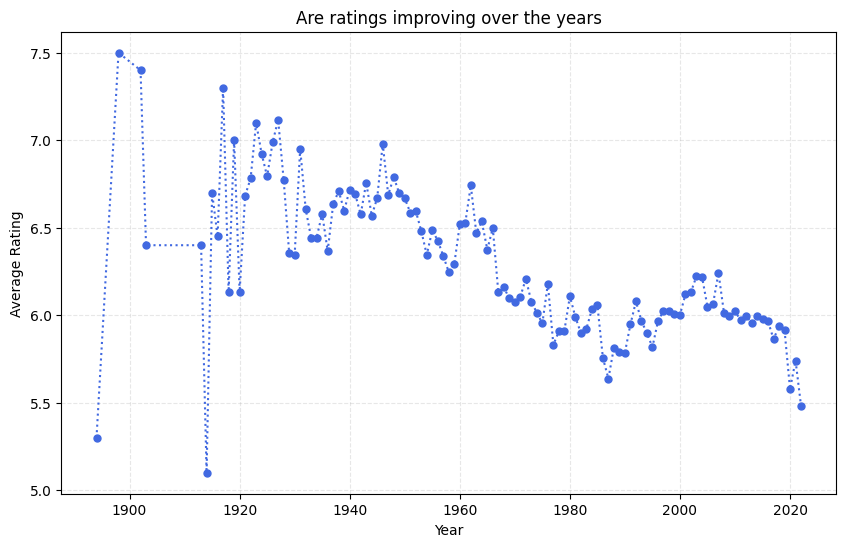

In [95]:
plt.figure(figsize=(10,6))
plt.plot(rpy.index,rpy.values,color='royalblue',marker='o',linestyle=':',markersize=5)
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.title('Are ratings improving over the years')
plt.grid(alpha=0.3,linestyle='--')
plt.show()

Conclusion : Ratings are decreasing over the years

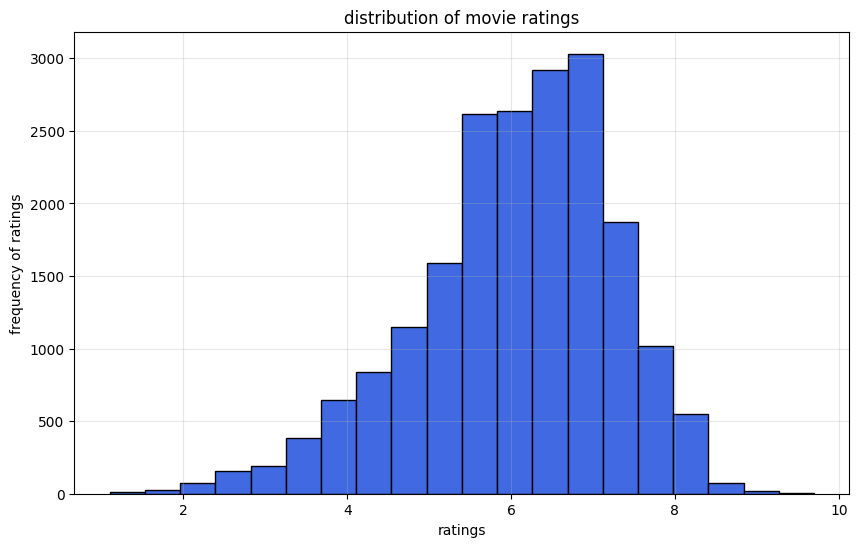

In [96]:
# Plot the distribution of movie ratings (Histogram using Matplotlib)
plt.figure(figsize=(10,6))
plt.hist(df['rating'],color='royalblue', edgecolor='black', bins =20)
plt.xlabel('ratings')
plt.ylabel('frequency of ratings')
plt.grid(alpha=0.3)
plt.title('distribution of movie ratings')
plt.show()

conclusion : left-skewed (negatively skewed) distribution,meaning that the majority of films are given above-average ratings rather than poor marks.

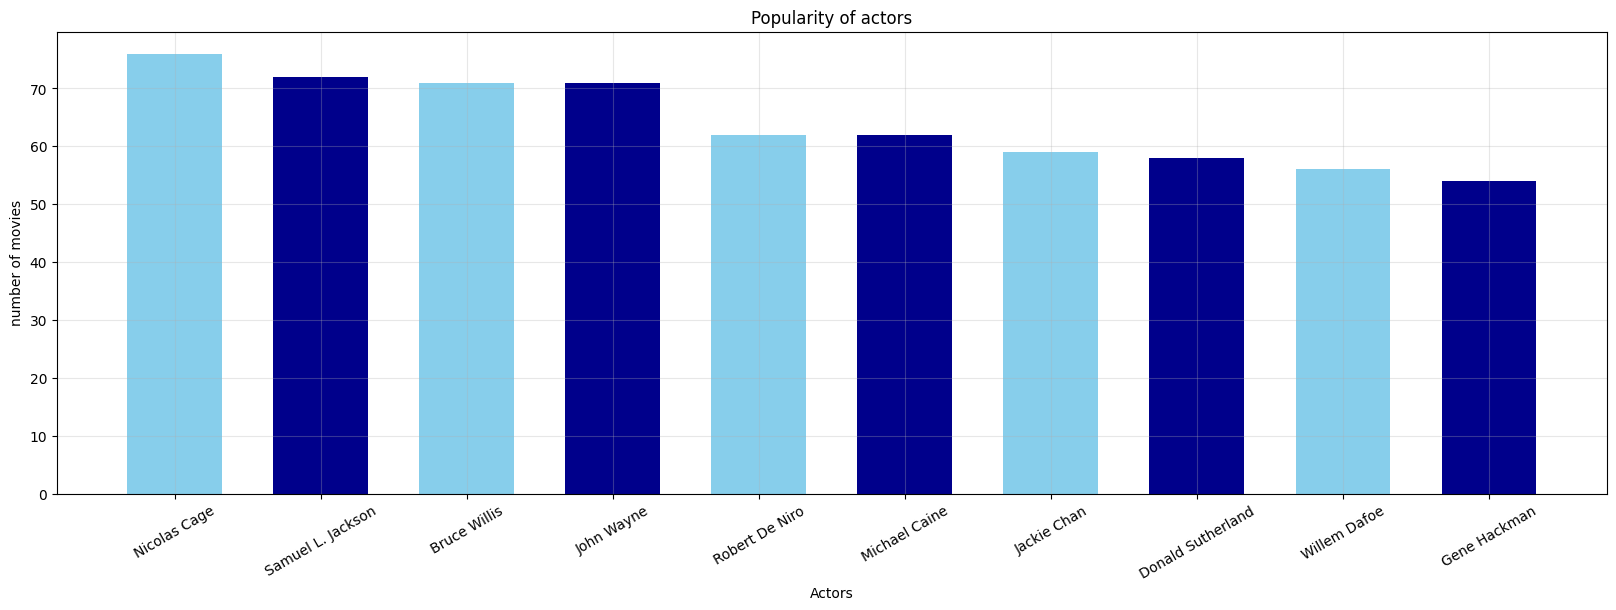

In [97]:
 #Which actor appears in the most movies?
x= df['stars_name'].str.split(',').explode().value_counts().sort_values(ascending = False).head(10)
plt.figure(figsize=(20,6))
plt.bar(x.index,x.values, color=['skyblue','darkblue'],width=0.65)
plt.xticks(rotation=30)
plt.xlabel('Actors')
plt.ylabel('number of movies')
plt.title('Popularity of actors')
plt.grid(alpha=0.3)
plt.show()


The top 10 most popular actors are shown in the plot above

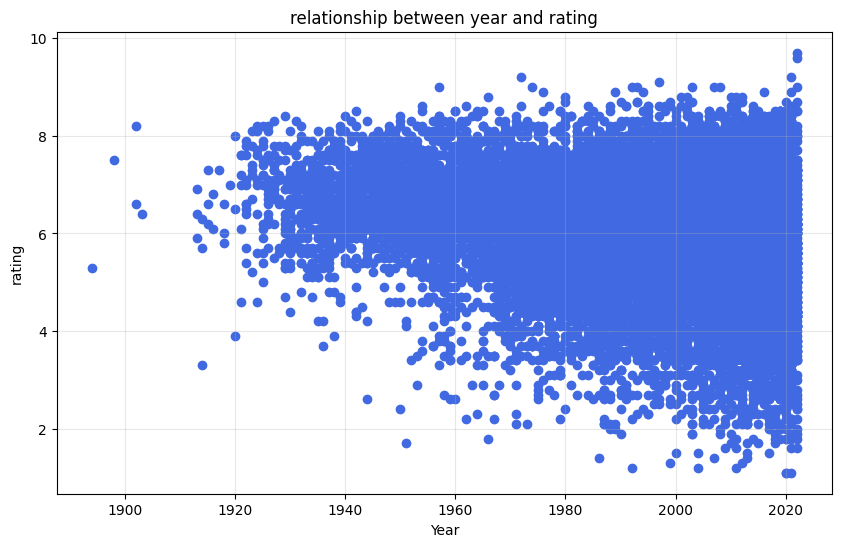

In [98]:
# What is the relationship between rating and years
plt.figure(figsize=(10,6))
plt.scatter(df['year'],df['rating'],marker='o',color='royalblue')
plt.xlabel('Year')
plt.ylabel('rating')
plt.title('relationship between year and rating')
plt.grid(alpha=0.3)
plt.show()

Conclusion: As the years progress, the spread of ratings expands heavily downwards, demonstrating a substantial increase in the volume of poorly rated films over time.

In [99]:
#  What is the correlation between Votes and Gross Income?
df[['votes','gross_income']].corr()

,votes,gross_income
votes,1.000000,0.632683
gross_income,0.632683,1.000000


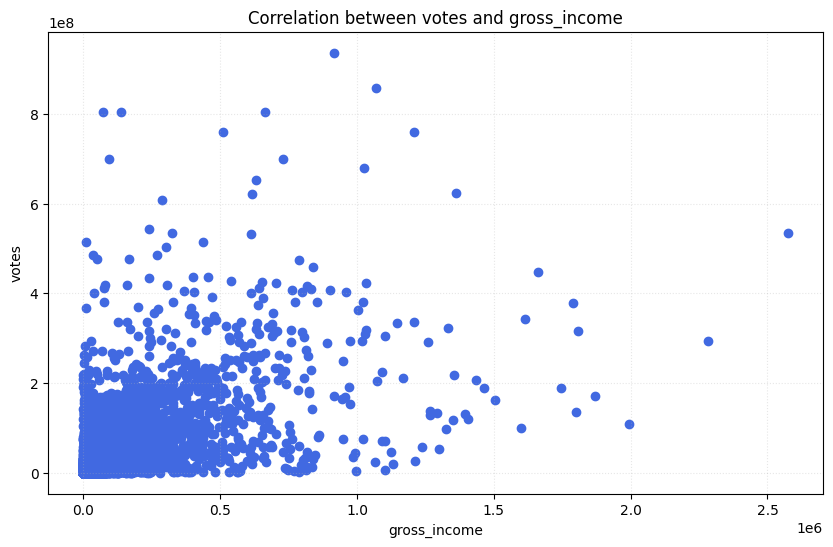

In [100]:
plt.figure(figsize=(10,6))
plt.scatter(df['votes'],df['gross_income'],marker='o',color='royalblue')
plt.xlabel('gross_income')
plt.ylabel('votes')
plt.title('Correlation between votes and gross_income')
plt.grid(alpha=0.3,linestyle=':')
plt.show()

Conclusion: Higher box office revenue shares a strong positive clustering with high vote counts, showing that financially successful movies drive significantly larger audience engagement and voting volume.

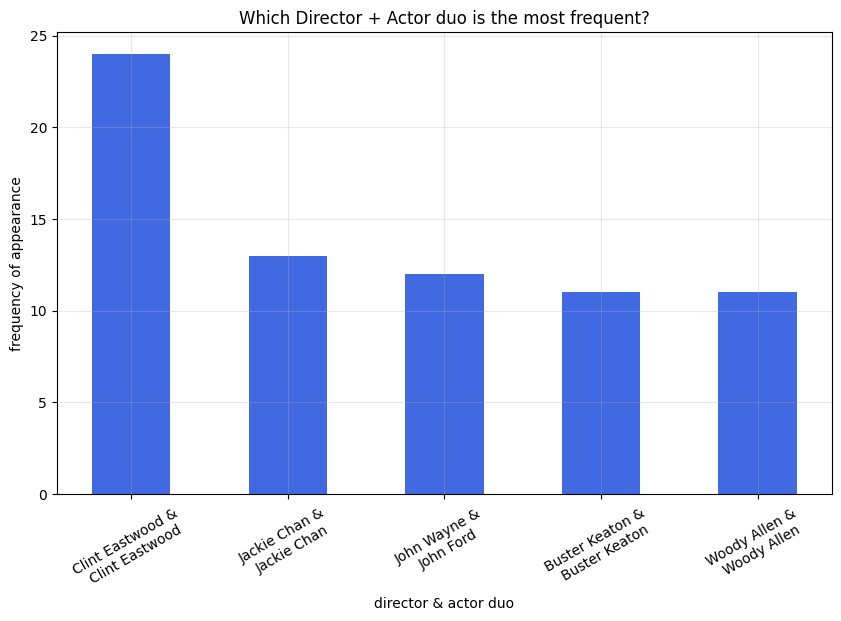

In [101]:
# Which Director + Actor duo is the most frequent?
x = df.assign(
    stars_name=df['stars_name'].str.split(','),
    directors_name=df['directors_name'].str.split(',')  # Added the ',' here!
).explode('stars_name').explode('directors_name')

x['stars_name'] = x['stars_name'].str.strip()
x['directors_name'] = x['directors_name'].str.strip()

result = x.groupby(['stars_name', 'directors_name']).size().reset_index(name='count')

result = result.sort_values(by='count', ascending=False).head(5)


plt.figure(figsize=(10,6))
labels=result['stars_name']+ ' & ' +'\n' + result['directors_name']
plt.bar(labels,result['count'],color='royalblue',width=0.50)
plt.xticks(rotation=30)
plt.xlabel('director & actor duo')
plt.ylabel('frequency of appearance')
plt.title('Which Director + Actor duo is the most frequent?')
plt.grid(alpha=0.3)
plt.show()

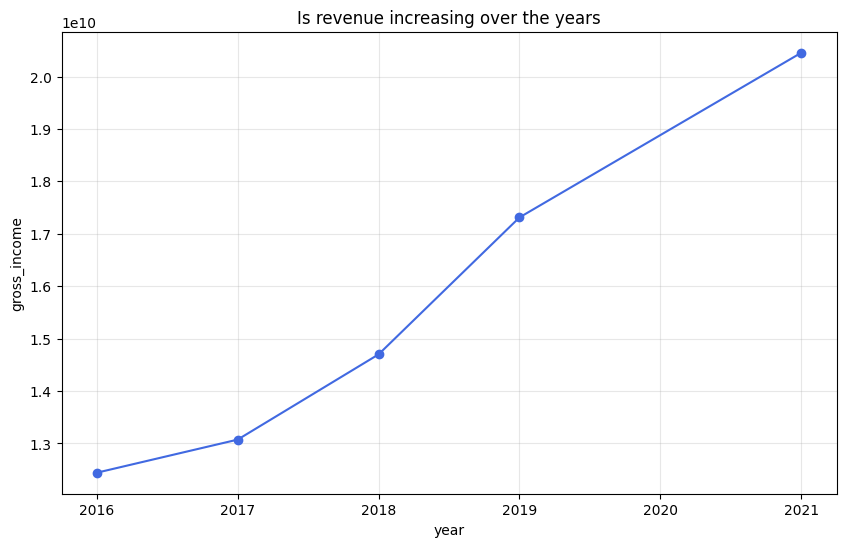

In [102]:
#  Which year had the highest total industry revenue?
x=df.groupby('year')['gross_income'].sum().sort_values(ascending=False).head(5)
plt.figure(figsize=(10,6))
plt.plot(x.index,x.values,marker='o',color='royalblue')
plt.xlabel('year')
plt.ylabel('gross_income')
plt.title('Is revenue increasing over the years')
plt.grid(alpha=0.3)
plt.show()

In [103]:
# What is the best genre for a debut director? (Highest avg rating for 1st time directors)
x=df.assign(genre=df['genre'].str.split(',')
, directors_name=df['directors_name'].str.split(',')).explode('genre').explode('directors_name')
x['genre'] = x['genre'].str.strip()
x['directors_name'] = x['directors_name'].str.strip()

debut_movies = x[x['year'] == x.groupby('directors_name')['year'].transform('min')]
result=debut_movies.groupby('genre')['rating'].mean().sort_values(ascending=False)
result.head(1)


,rating
genre,
Documentary,7.182909


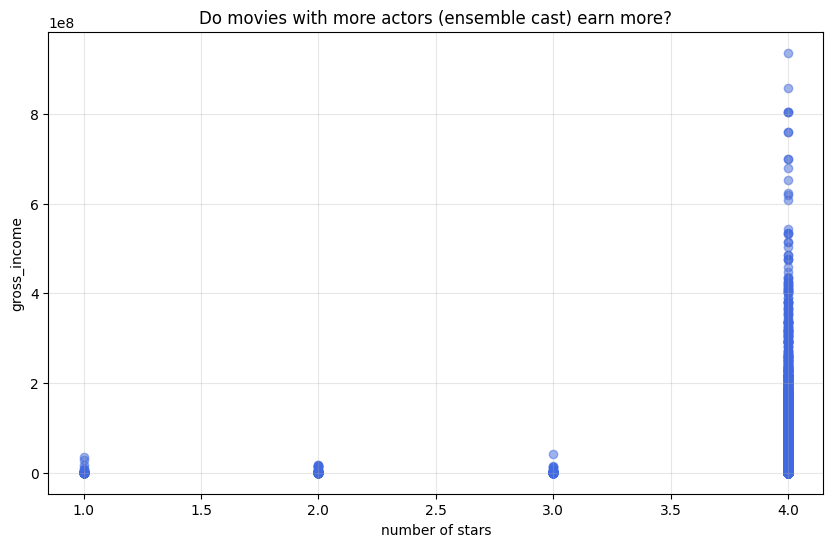

In [104]:
#  Do movies with more actors (ensemble cast) earn more?

stars_list = df['stars_name'].str.split(',')
stars_count = stars_list.str.len()

df.assign(stars_count=stars_count)[['gross_income','stars_count']].corr()
x=df.assign(stars_count=stars_count)
plt.figure(figsize=(10,6))
plt.scatter(x['stars_count'],x['gross_income'],alpha=0.5,color='royalblue')
plt.xlabel('number of stars')
plt.ylabel('gross_income')
plt.title('Do movies with more actors (ensemble cast) earn more?')
plt.grid(alpha=0.3)

conclusion : It means that having more number of main actors opens the door to hitting that maximum gross income, but it doesn't automatically guarantee it, it can earn less too

In [105]:
#  Which Director has the highest "Hit Rate"? (Percentage of movies rated > 7.5)
x=df.assign(directors=df['directors_name'].str.split(',')).explode('directors')
x['directors']=x['directors'].str.strip()
x['is_hit']=x['rating']>7.5
stats=x.groupby('directors')['is_hit'].agg(
    hit_rate=lambda g : g.mean()*100,
    movie_count='size'
)
dir=stats[stats['movie_count']>5]
result=dir.sort_values(by='hit_rate',ascending=False).head(10)



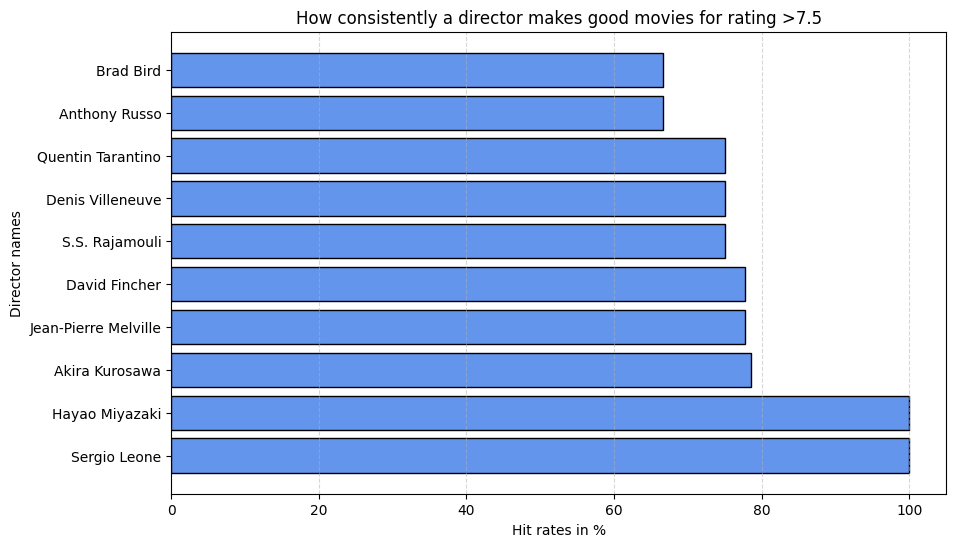

In [106]:
# How consistently a director makes good movies
plt.figure(figsize=(10,6))
plt.barh(result.index,result['hit_rate'],color='cornflowerblue',edgecolor='black',linestyle='-')
plt.xlabel('Hit rates in %')
plt.ylabel('Director names')
plt.title('How consistently a director makes good movies for rating >7.5')
plt.grid(axis='x',linestyle='--',alpha=0.5)

Conclusion: By isolating directors with over 5 films, this visualization spotlights the top 10 elite filmmakers who maintain the highest historical percentages of critically acclaimed "hits".

In [107]:
#  Analyse the "Sequel Effect" — Do movies with numbers in titles earn more?
x=df['name'].str.strip()
df['is_digit']=x.str.contains(r'\s[2-9]$', na=False)
df['is_digit']=df['is_digit'].map({True:'Sequel',False:'Non Sequel'})
result=df.groupby('is_digit')['gross_income'].mean()


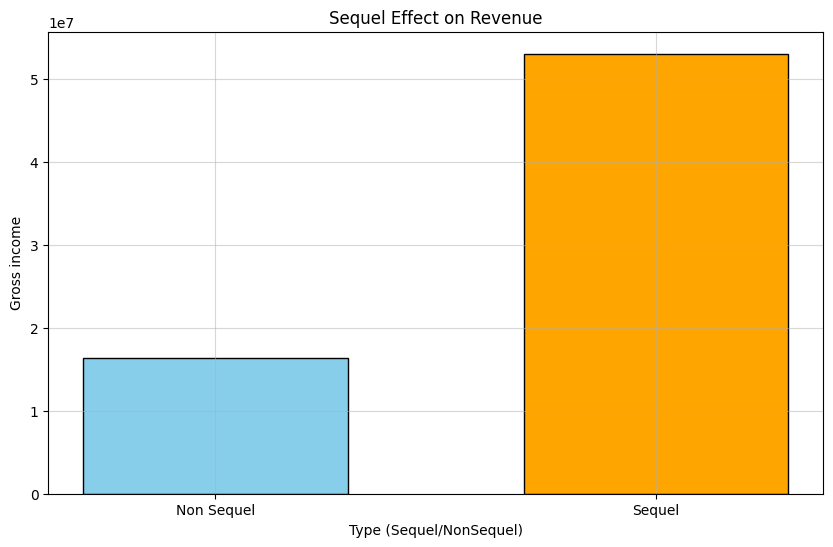

In [108]:
plt.figure(figsize=(10,6))
plt.bar(result.index,result.values,color=['skyblue','orange'],edgecolor='black',width=0.6)
plt.grid(alpha=0.5)
plt.ylabel('Gross income')
plt.xlabel('Type (Sequel/NonSequel)')
plt.title('Sequel Effect on Revenue')
plt.show()

Conclusion: Sequels (movies designated with ending digits) carry an immense competitive advantage, generating significantly higher average gross incomes compared to non-sequel titles.

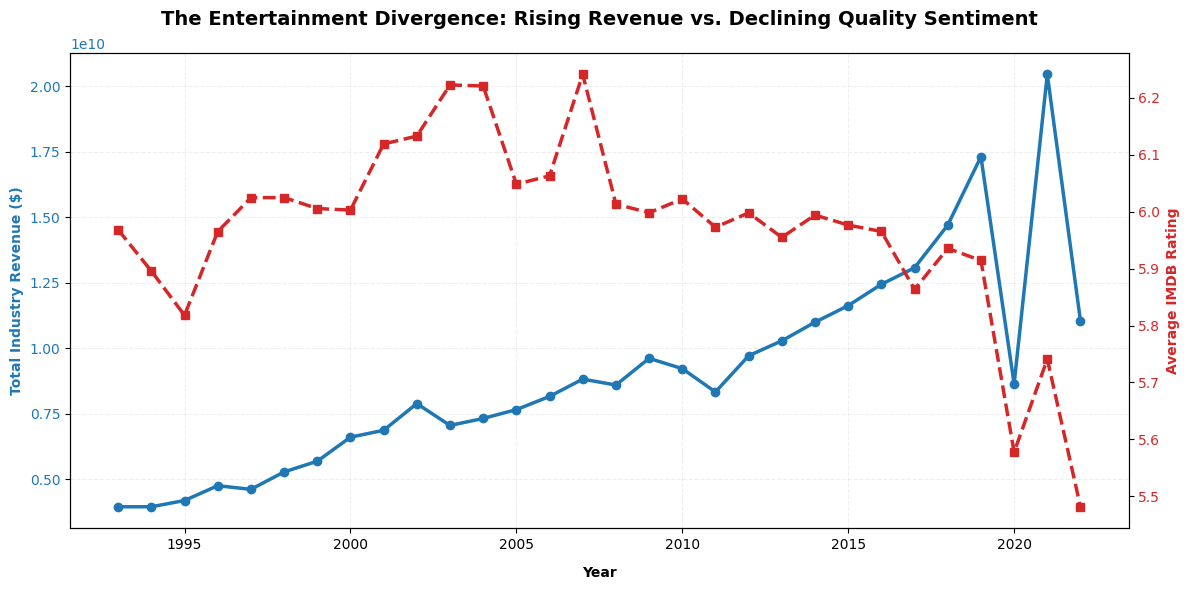

In [110]:
# Aggregate both metrics chronologically by year
macro_trends = df.groupby('year').agg({
    'gross_income': 'sum',
    'rating': 'mean'
}).sort_index()

# analysis for recent 30 years
macro_trends = macro_trends.tail(30)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Plotting Gross Income on Primary Y-Axis
color = '#1f77b4'
ax1.set_xlabel('Year', fontweight='bold', labelpad=10)
ax1.set_ylabel('Total Industry Revenue ($)', color=color, fontweight='bold')
ax1.plot(macro_trends.index, macro_trends['gross_income'], color=color, linewidth=2.5, marker='o', label='Total Revenue')
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.2, linestyle='--')

# Creating a Twin Axis for Ratings
ax2 = ax1.twinx()
color = '#d62728'
ax2.set_ylabel('Average IMDB Rating', color=color, fontweight='bold')
ax2.plot(macro_trends.index, macro_trends['rating'], color=color, linewidth=2.5, linestyle='--', marker='s', label='Avg Rating')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('The Entertainment Divergence: Rising Revenue vs. Declining Quality Sentiment',
          fontsize=14, fontweight='bold', pad=20)
fig.tight_layout()

plt.show()

# Executive Summary & Strategic Business Decisions

Based on what the data shows us about movie history, we have created a three-step game plan to help our studio spend money smarter, avoid expensive flops, and make the biggest possible profit.

---

### Step 1: Play It Safe with Proven Teams
* **What the Data Says:** There is a specific group of directors who almost always make hit movies (scoring over 7.5/10 more than 75% of the time). On top of that, certain directors and actors work incredibly well together over and over again.
* **The Business Decision:** **Stop fighting over risky, one-off projects and lock down long-term contracts.** The studio should sign multi-movie deals with these highly reliable director-and-actor teams. This takes the guesswork out of filmmaking and guarantees we are working with people who know how to deliver quality.

### Step 2: Focus on Franchises and Sequels (The "Sequel Advantage")
* **What the Data Says:** Even though overall movie ratings from audiences have been slowly dropping over the years, the financial reality is simple: **Sequels make way more money on average than original, standalone movies.**
* **The Business Decision:** **Build movie universes instead of one-hit wonders.** Instead of wasting money on risky, unproven scripts, we should spend our budget on movies that can turn into franchises, spin-offs, or sequels. Every time we greenlight a brand-new movie, the contract must state that our studio owns the rights to make Part 2 and Part 3.

### Step 3: Market to the Crowd, Not the Critics
* **What the Data Says:** Things like how long a movie lasts (duration) have almost no effect on how much people like it. However, there is a massive connection between **how many people vote on a movie** (votes) and **how much money it makes** (gross_income).
* **The Business Decision:** **Stop trying to please fancy critics and focus on getting regular audiences talking.** Big box office numbers are driven by hype, crowd excitement, and online chatter - not perfect reviews. We should shift our marketing budgets away from traditional "prestige" campaigns and focus heavily on digital, interactive social media campaigns that get millions of regular people talking, sharing, and voting online.


> ### Proposed Next-Phase Enhancements


> To take this project to the next level, the next phase will merge this performance data with **inflation-adjusted production budgets**. This will allow us to move from measuring simple gross income to calculating true **Return on Investment (ROI)** and financial profit margins per genre.